#Exercises XP Or cnn

In [5]:
# Exercises XP Or : Quatre projets CNN
# Chaque exercice explore une technique différente

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report


# Noms des classes CIFAR-10
CLASS_NAMES = [
    'avion', 'voiture', 'oiseau', 'chat', 'cerf',
    'chien', 'grenouille', 'cheval', 'bateau', 'camion'
]

# Chargement et préparation du dataset CIFAR-10 (utilisé par tous les exercices)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

y_train_enc = to_categorical(y_train, 10)
y_test_enc  = to_categorical(y_test,  10)

print("Dataset CIFAR-10 chargé :")
print(f"Train : {x_train.shape} | Test : {x_test.shape}")


Dataset CIFAR-10 chargé :
Train : (50000, 32, 32, 3) | Test : (10000, 32, 32, 3)


EXERCICE 1 : Classification d'objets du quotidien (CIFAR-10)

In [6]:
# EXERCICE 1 : Classification d'objets du quotidien (CIFAR-10)
# Objectif : construire un CNN avec data augmentation pour améliorer la robustesse

print("\nExercice 1 : Classification d'objets CIFAR-10")

# Augmentation des données pour rendre le modèle robuste aux variations
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def build_cifar_model():
    model = keras.Sequential([
        # Couche d'augmentation active uniquement pendant l'entraînement
        augmentation,

        # Bloc 1 : détection de patterns simples
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Bloc 2 : patterns intermédiaires
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Bloc 3 : patterns complexes
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_ex1 = build_cifar_model()
model_ex1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ex1 = model_ex1.fit(
    x_train, y_train_enc,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

_, acc_ex1 = model_ex1.evaluate(x_test, y_test_enc, verbose=0)
print(f"Exercice 1 - Accuracy : {acc_ex1*100:.2f}%")


Exercice 1 : Classification d'objets CIFAR-10
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 355s 496ms/step - accuracy: 0.3284 - loss: 1.8642 - val_accuracy: 0.3912 - val_loss: 1.6411
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 384s 499ms/step - accuracy: 0.4408 - loss: 1.5520 - val_accuracy: 0.5094 - val_loss: 1.3891
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 382s 500ms/step - accuracy: 0.4943 - loss: 1.4121 - val_accuracy: 0.5582 - val_loss: 1.3006
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 349s 496ms/step - accuracy: 0.5347 - loss: 1.3116 - val_accuracy: 0.5218 - val_loss: 1.6971
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 379s 491ms/step - accuracy: 0.5679 - loss: 1.2388 - val_accuracy: 0.6194 - val_loss: 1.1055
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 382s 492ms/step - accuracy: 0.5901 - loss: 1.1736 - val_accuracy: 0.6108 - val_loss: 1.1260
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 341s 484ms/step - accuracy: 0.6128 - loss: 1.1259 - val_accuracy: 0.6146 - val_loss: 1.1583
Epoch 8/20
704/704 ━━━━━━━━━━

EXERCICE 2 : Classification avec données limitées

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.1250 - loss: 2.3099 - val_accuracy: 0.1700 - val_loss: 2.2859
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.1531 - loss: 2.2475 - val_accuracy: 0.1675 - val_loss: 2.2201
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.1881 - loss: 2.1679 - val_accuracy: 0.2400 - val_loss: 2.1567
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.2125 - loss: 2.1041 - val_accuracy: 0.2225 - val_loss: 2.1016
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.2375 - loss: 2.0448 - val_accuracy: 0.3000 - val_loss: 2.0368
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2637 - loss: 1.9618 - val_accuracy: 0.2800 - val_loss: 1.9233
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2950 - loss: 1.8973 - val_accuracy: 0.3550 - val_loss: 1.8896
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3137 - loss: 1.8670 - val_accuracy: 0.3450 - v

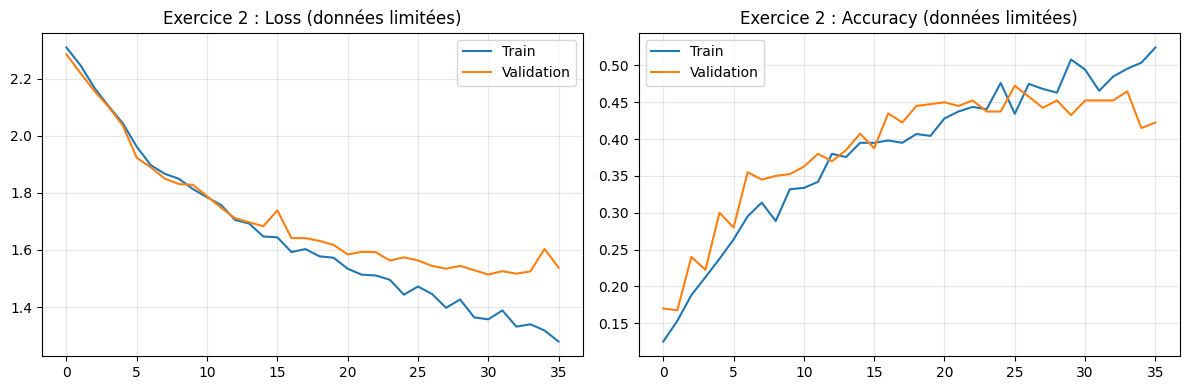

In [7]:
#EXERCICE 2 : Classification avec données limitées
# Objectif : prévenir l'overfitting avec un petit dataset


# Utiliser seulement 2000 images pour simuler un petit dataset
x_small = x_train[:2000]
y_small = y_train_enc[:2000]

# Architecture plus petite pour éviter l'overfitting sur peu de données
model_ex2 = keras.Sequential([
    # Architecture volontairement légère
    layers.Conv2D(16, (3, 3), activation='relu', padding='same',
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.3),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_ex2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping pour éviter l'overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_ex2 = model_ex2.fit(
    x_small, y_small,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

_, acc_ex2 = model_ex2.evaluate(x_test, y_test_enc, verbose=0)
print(f"Exercice 2 - Accuracy (2000 images) : {acc_ex2*100:.2f}%")

# Analyser l'impact de chaque technique anti-overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_ex2.history['loss'],     label='Train')
ax1.plot(history_ex2.history['val_loss'], label='Validation')
ax1.set_title('Exercice 2 : Loss (données limitées)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_ex2.history['accuracy'],     label='Train')
ax2.plot(history_ex2.history['val_accuracy'], label='Validation')
ax2.set_title('Exercice 2 : Accuracy (données limitées)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

EXERCICE 3 : Transfer Learning pour l'extraction de features

In [8]:
# EXERCICE 3 : Transfer Learning pour l'extraction de features
# Objectif : utiliser MobileNetV2 pour extraire des features sans réentraîner

print("\nExercice 3 : Transfer Learning avec MobileNetV2")

# Chargement de MobileNetV2 pré-entraîné sans la tête de classification
base_model = keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,    # On retire la couche de classification d'origine
    weights='imagenet'    # Poids appris sur 1.2 million d'images ImageNet
)

# Geler toutes les couches du modèle de base
# On ne réentraîne que notre nouvelle tête de classification
base_model.trainable = False

# Construire le modèle complet avec notre propre tête
model_ex3 = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Réduire les feature maps en vecteur
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_ex3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Exercice 3 : Transfer Learning avec MobileNetV2


/tmp/ipykernel_52998/884932034.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [9]:
# Phase 1 : entraîner seulement la tête
print("Phase 1 : entraînement de la tête uniquement")
history_ex3_p1 = model_ex3.fit(
    x_train, y_train_enc,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

_, acc_ex3_p1 = model_ex3.evaluate(x_test, y_test_enc, verbose=0)
print(f"Phase 1 - Accuracy : {acc_ex3_p1*100:.2f}%")

Phase 1 : entraînement de la tête uniquement
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.2780 - loss: 1.9897 - val_accuracy: 0.3278 - val_loss: 1.8723
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.3144 - loss: 1.8846 - val_accuracy: 0.3458 - val_loss: 1.8316
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.3249 - loss: 1.8542 - val_accuracy: 0.3540 - val_loss: 1.8133
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.3333 - loss: 1.8323 - val_accuracy: 0.3540 - val_loss: 1.8027
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.3393 - loss: 1.8179 - val_accuracy: 0.3560 - val_loss: 1.7913
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.3443 - loss: 1.8041 - val_accuracy: 0.3560 - val_loss: 1.7808
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.3497 - loss: 1.7933 - val_accuracy: 0.3546 - val_loss: 1.7807
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 7

In [ ]:
# Phase 2 : fine-tuning en dégelant les dernières couches
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Learning rate plus faible pour ne pas détruire les poids pré-entraînés
model_ex3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 : fine-tuning des dernières couches")
history_ex3_p2 = model_ex3.fit(
    x_train, y_train_enc,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

_, acc_ex3_p2 = model_ex3.evaluate(x_test, y_test_enc, verbose=0)
print(f"Phase 2 - Accuracy après fine-tuning : {acc_ex3_p2*100:.2f}%")

# Comparaison avec un modèle entraîné from scratch
model_scratch = build_cifar_model()
model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_scratch.fit(
    x_train, y_train_enc,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
_, acc_scratch = model_scratch.evaluate(x_test, y_test_enc, verbose=0)

print(f"\nFrom scratch    : {acc_scratch*100:.2f}%")
print(f"Transfer Learning : {acc_ex3_p2*100:.2f}%")

Phase 2 : fine-tuning des dernières couches
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 155ms/step - accuracy: 0.3086 - loss: 5.0425 - val_accuracy: 0.1504 - val_loss: 12.7120
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 167ms/step - accuracy: 0.3908 - loss: 1.7298 - val_accuracy: 0.3030 - val_loss: 2.2131
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 108s 154ms/step - accuracy: 0.4547 - loss: 1.5409 - val_accuracy: 0.3876 - val_loss: 1.6791
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 108s 154ms/step - accuracy: 0.4948 - loss: 1.4220 - val_accuracy: 0.4482 - val_loss: 1.5482
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 108s 153ms/step - accuracy: 0.5303 - loss: 1.3280 - val_accuracy: 0.4922 - val_loss: 1.4228
Phase 2 - Accuracy après fine-tuning : 49.08%


EXERCICE 4 : Visualisation des filtres CNN

In [ ]:
# EXERCICE 4 : Visualisation des filtres CNN
# Objectif : comprendre ce que le CNN a appris en visualisant ses filtres

print("\nExercice 4 : Visualisation des filtres appris")

# Entraîner un CNN simple sur MNIST pour avoir des filtres plus lisibles
(mnist_train, mnist_y_train), (mnist_test, mnist_y_test) = \
    keras.datasets.mnist.load_data()

mnist_train = mnist_train.reshape(-1, 28, 28, 1) / 255.0
mnist_y_enc = to_categorical(mnist_y_train, 10)

model_ex4 = keras.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1),
                  name='conv_first'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_ex4.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ex4.fit(
    mnist_train, mnist_y_enc,
    epochs=5,
    batch_size=32,
    verbose=0
)

# Récupérer les filtres de la première couche de convolution
first_layer = model_ex4.get_layer('conv_first')
filters, biases = first_layer.get_weights()

print(f"Forme des filtres : {filters.shape}")  # (3, 3, 1, 16) = 16 filtres 3x3

# Normaliser les filtres pour la visualisation
f_min = filters.min()
f_max = filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

# Afficher les 16 filtres de la première couche
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    # Afficher chaque filtre (3x3 pixels)
    ax.imshow(filters_norm[:, :, 0, i], cmap='gray')
    ax.set_title(f'Filtre {i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('Filtres appris par la première couche Conv2D', fontsize=12)
plt.tight_layout()
plt.show()

# Visualiser l'activation produite par chaque filtre sur une image
sample_img = mnist_train[0:1]  # Une seule image

# Créer un modèle intermédiaire qui sort les activations de la première couche
activation_model = keras.Model(
    inputs=model_ex4.input,
    outputs=model_ex4.get_layer('conv_first').output
)

activations = activation_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(activations[0, :, :, i], cmap='viridis')
    ax.set_title(f'Activation {i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('Activations produites par chaque filtre sur une image', fontsize=12)
plt.tight_layout()
plt.show()

print("Les filtres détectent des bords horizontaux, verticaux et diagonaux.")
print("Chaque filtre est spécialisé dans un type de pattern visuel.")